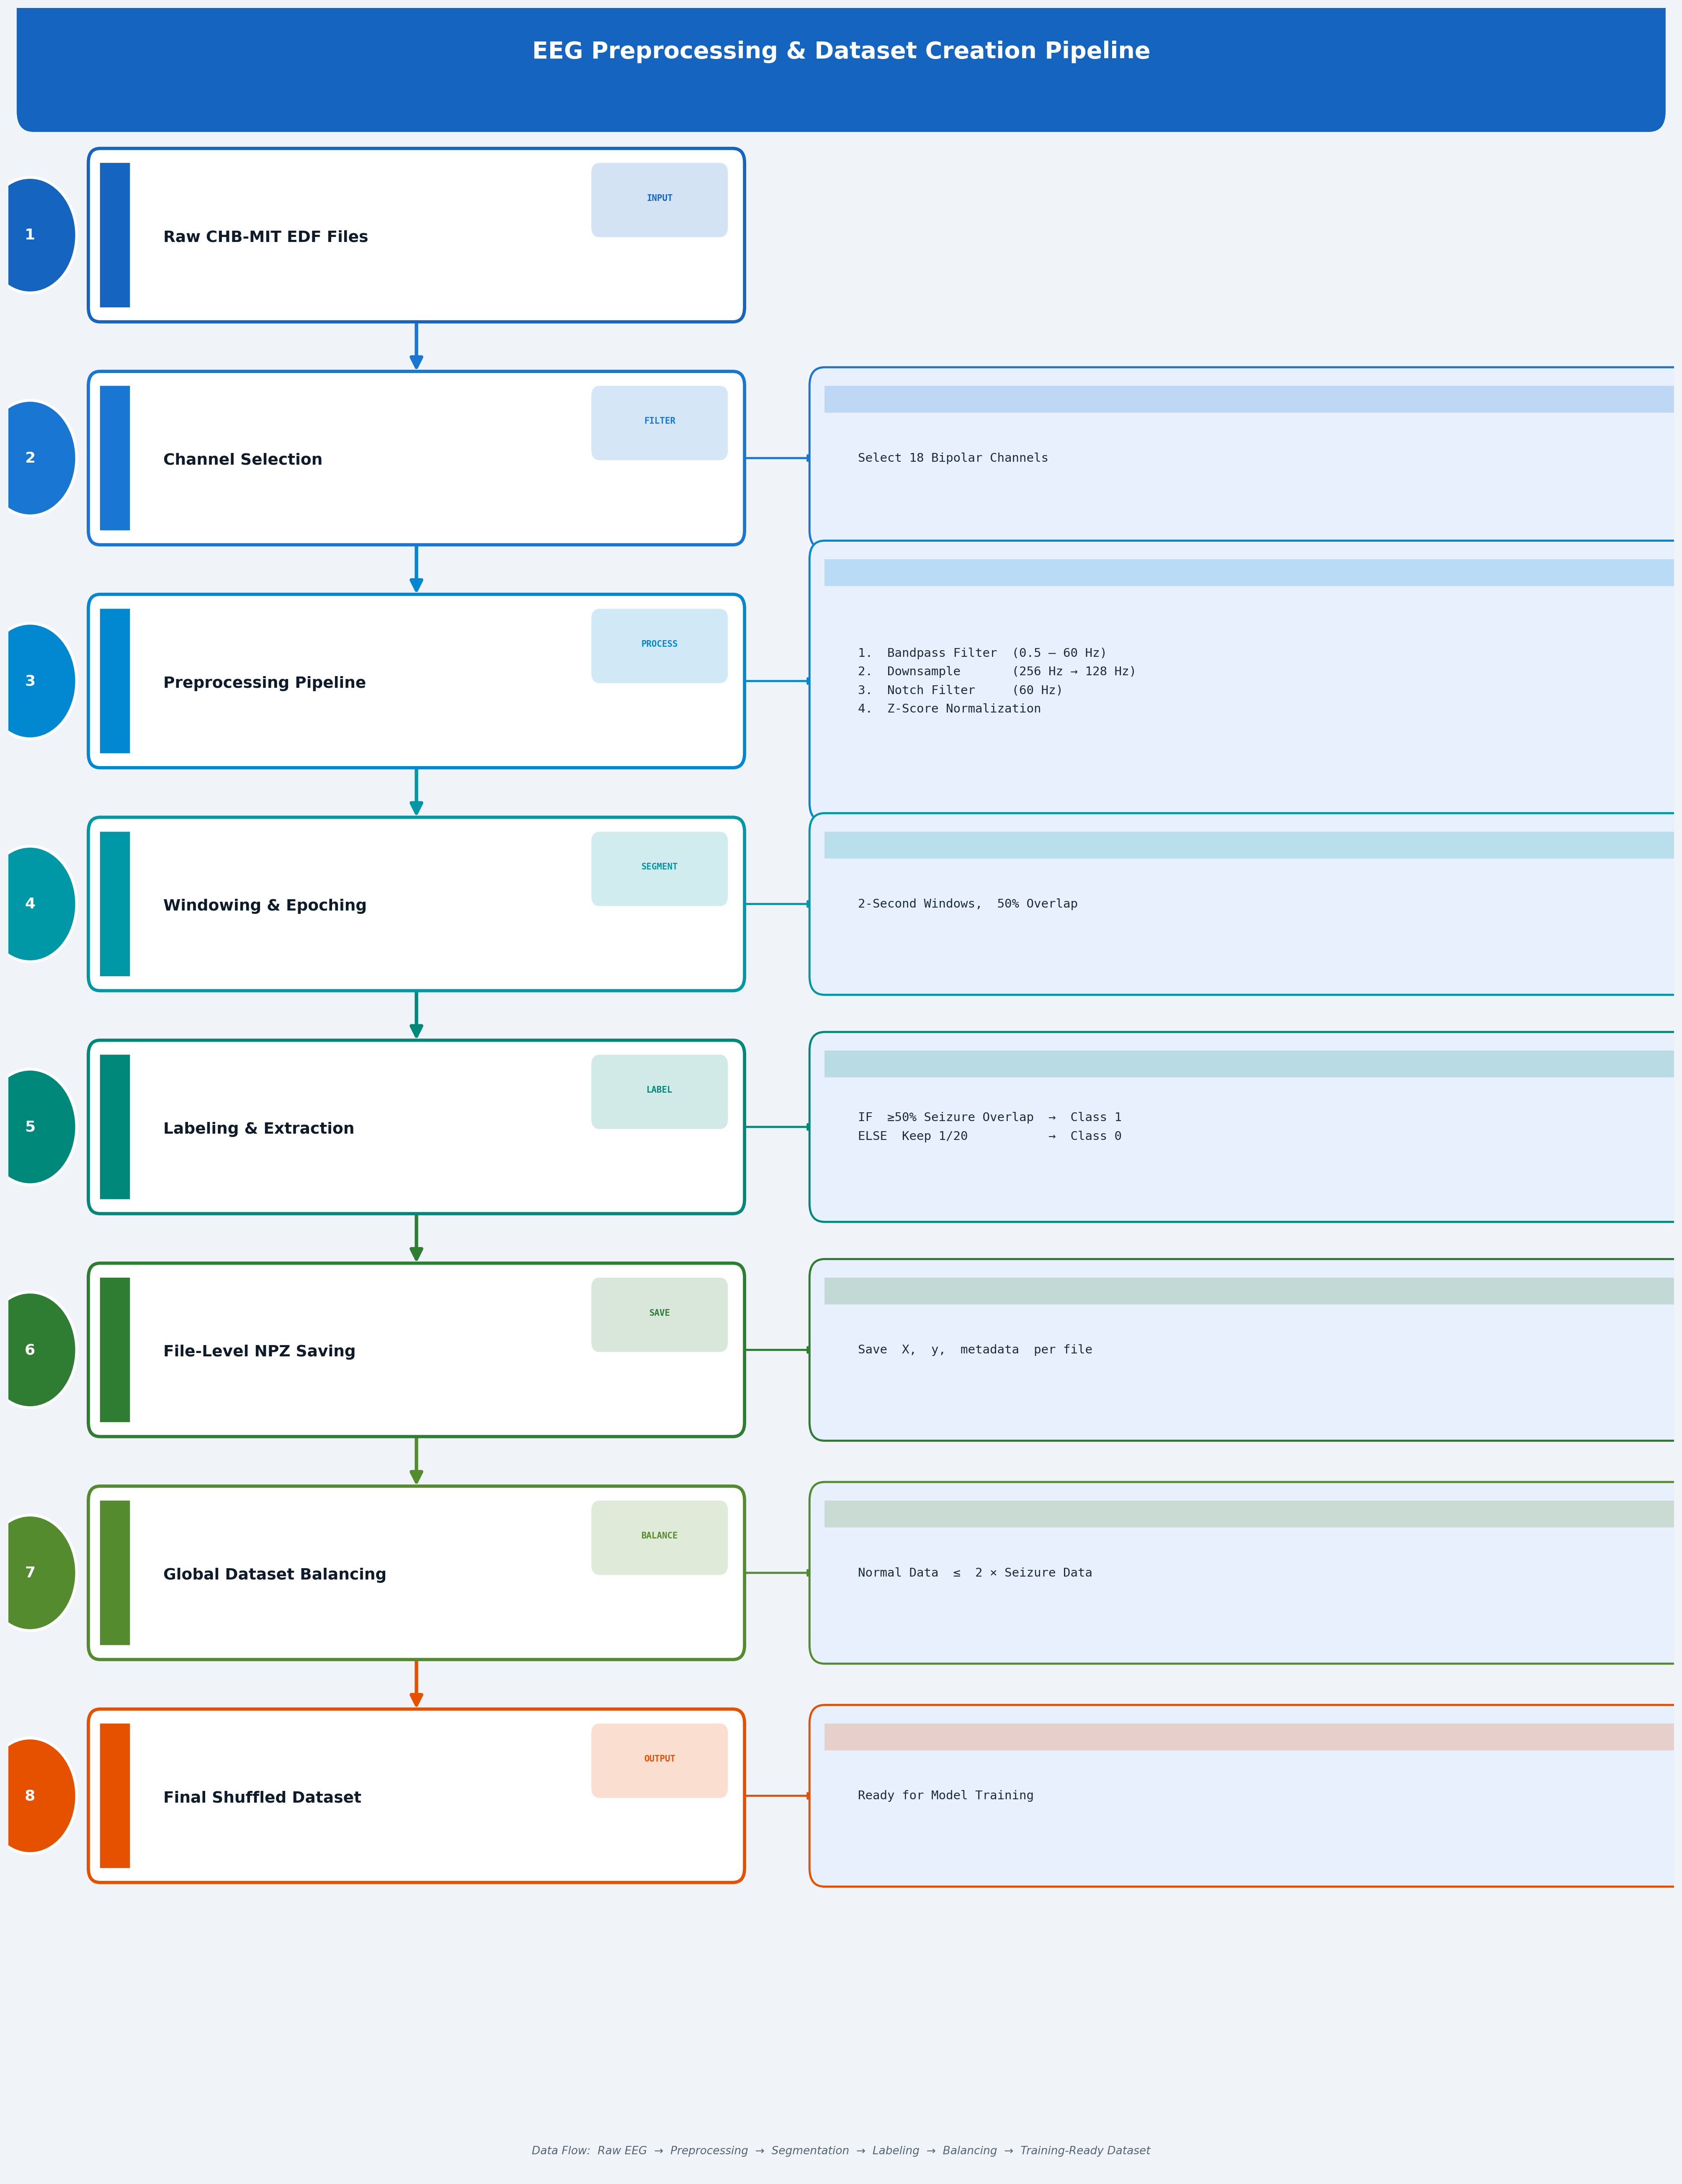

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patheffects as pe
import numpy as np

# ── Pipeline step definitions ───────────────────────────────────────────────
steps = [
    {
        "title": "Raw CHB-MIT EDF Files",
        "desc": None,
        "tag": "INPUT",
        "tag_color": "#1565C0",
    },
    {
        "title": "Channel Selection",
        "desc": "Select 18 Bipolar Channels",
        "tag": "FILTER",
        "tag_color": "#1976D2",
    },
    {
        "title": "Preprocessing Pipeline",
        "desc": (
            "1.  Bandpass Filter  (0.5 – 60 Hz)\n"
            "2.  Downsample       (256 Hz → 128 Hz)\n"
            "3.  Notch Filter     (60 Hz)\n"
            "4.  Z-Score Normalization"
        ),
        "tag": "PROCESS",
        "tag_color": "#0288D1",
    },
    {
        "title": "Windowing & Epoching",
        "desc": "2-Second Windows,  50% Overlap",
        "tag": "SEGMENT",
        "tag_color": "#0097A7",
    },
    {
        "title": "Labeling & Extraction",
        "desc": "IF  ≥50% Seizure Overlap  →  Class 1\nELSE  Keep 1/20           →  Class 0",
        "tag": "LABEL",
        "tag_color": "#00897B",
    },
    {
        "title": "File-Level NPZ Saving",
        "desc": "Save  X,  y,  metadata  per file",
        "tag": "SAVE",
        "tag_color": "#2E7D32",
    },
    {
        "title": "Global Dataset Balancing",
        "desc": "Normal Data  ≤  2 × Seizure Data",
        "tag": "BALANCE",
        "tag_color": "#558B2F",
    },
    {
        "title": "Final Shuffled Dataset",
        "desc": "Ready for Model Training",
        "tag": "OUTPUT",
        "tag_color": "#E65100",
    },
]

# ── Layout constants ─────────────────────────────────────────────────────────
FIG_W, FIG_H   = 20, 26          # inches
DPI            = 200

LEFT_COL_X     = 0.55            # left edge of left box  (data units 0–10)
LEFT_COL_W     = 3.8             # width of left box
LEFT_COL_H     = 0.70            # height of left box
BADGE_R        = 0.28            # radius of step-number badge
BADGE_X_OFFSET = 0.42            # badge centre to the LEFT of box left edge

RIGHT_COL_X    = LEFT_COL_X + LEFT_COL_W + 0.55   # left edge of right box
RIGHT_COL_W    = 5.50            # width of right box

Y_START        = 9.10
Y_STEP         = 1.08

# Background colour for the whole figure
BG_COLOR       = "#F0F4F8"

# ── Colour palette – one per step (8 distinct hues) ─────────────────────────
STEP_COLORS = [
    "#1565C0",  # 1 deep blue
    "#1976D2",  # 2
    "#0288D1",  # 3 mid blue
    "#0097A7",  # 4 teal
    "#00897B",  # 5 green-teal
    "#2E7D32",  # 6 dark green
    "#558B2F",  # 7 olive-green
    "#E65100",  # 8 deep orange (output)
]

LEFT_BOX_FACE  = "#FFFFFF"       # white cards  → max contrast for dark text
LEFT_BOX_ALPHA = 1.0
RIGHT_BOX_FACE = "#E8F0FE"       # very light lavender for info panels
RIGHT_BOX_ALPHA= 1.0

# ── Figure setup ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), dpi=DPI)
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)
ax.set_xlim(0, 10)
ax.set_ylim(-0.3, 10.2)
ax.axis("off")

# ── Header banner ────────────────────────────────────────────────────────────
header = FancyBboxPatch(
    (0.15, 9.70), 9.70, 0.58,
    boxstyle="round,pad=0.10",
    edgecolor="#1565C0", facecolor="#1565C0", lw=0, alpha=1.0,
    zorder=2,
)
ax.add_patch(header)
ax.text(
    5.0, 9.99,
    "EEG Preprocessing & Dataset Creation Pipeline",
    ha="center", va="center",
    fontsize=20, fontweight="bold", color="white",
    fontfamily="DejaVu Sans", zorder=3,
)

# ── Helper: multi-line text height estimator ─────────────────────────────────
def line_count(text):
    return text.count("\n") + 1

# ── Draw each step ───────────────────────────────────────────────────────────
for i, step in enumerate(steps):
    y_centre = Y_START - i * Y_STEP
    color    = STEP_COLORS[i]

    # ── Left box (main step) ─────────────────────────────────────────────────
    lbox = FancyBboxPatch(
        (LEFT_COL_X, y_centre - LEFT_COL_H / 2),
        LEFT_COL_W, LEFT_COL_H,
        boxstyle="round,pad=0.07",
        edgecolor=color, facecolor=LEFT_BOX_FACE,
        lw=2.8, alpha=LEFT_BOX_ALPHA, zorder=4,
    )
    ax.add_patch(lbox)

    # coloured left accent bar
    accent_bar = FancyBboxPatch(
        (LEFT_COL_X, y_centre - LEFT_COL_H / 2),
        0.18, LEFT_COL_H,
        boxstyle="round,pad=0.0",
        edgecolor="none", facecolor=color,
        lw=0, alpha=1.0, zorder=5,
        clip_on=True,
    )
    ax.add_patch(accent_bar)

    # ── Badge (step number) ──────────────────────────────────────────────────
    badge = mpatches.Circle(
        (LEFT_COL_X - BADGE_X_OFFSET, y_centre), BADGE_R,
        color=color, ec="white", linewidth=2.5, zorder=6,
    )
    ax.add_patch(badge)
    ax.text(
        LEFT_COL_X - BADGE_X_OFFSET, y_centre,
        str(i + 1),
        ha="center", va="center",
        fontsize=13, fontweight="bold", color="white", zorder=7,
    )

    # ── Tag pill ─────────────────────────────────────────────────────────────
    tag_x = LEFT_COL_X + LEFT_COL_W - 0.08
    tag_y = y_centre + LEFT_COL_H / 2 - 0.17
    pill = FancyBboxPatch(
        (tag_x - 0.72, tag_y - 0.14), 0.72, 0.26,
        boxstyle="round,pad=0.05",
        edgecolor="none", facecolor=color,
        lw=0, alpha=0.18, zorder=5,
    )
    ax.add_patch(pill)
    ax.text(
        tag_x - 0.36, tag_y,
        step["tag"],
        ha="center", va="center",
        fontsize=7.5, fontweight="bold", color=color,
        fontfamily="monospace", zorder=6,
    )

    # ── Step title ───────────────────────────────────────────────────────────
    ax.text(
        LEFT_COL_X + 0.38, y_centre - 0.01,
        step["title"],
        ha="left", va="center",
        fontsize=13.5, fontweight="bold", color="#0D1B2A",
        fontfamily="DejaVu Sans", zorder=5,
    )

    # ── Right description box ────────────────────────────────────────────────
    if step["desc"]:
        n_lines   = line_count(step["desc"])
        r_height  = max(LEFT_COL_H, 0.30 + n_lines * 0.22)

        # connector
        conn_y = y_centre
        ax.annotate(
            "", xy=(RIGHT_COL_X - 0.04, conn_y),
            xytext=(LEFT_COL_X + LEFT_COL_W + 0.04, conn_y),
            arrowprops=dict(
                arrowstyle="-|>",
                color=color, lw=1.8,
                mutation_scale=12,
            ),
            zorder=3,
        )

        rbox = FancyBboxPatch(
            (RIGHT_COL_X, y_centre - r_height / 2),
            RIGHT_COL_W, r_height,
            boxstyle="round,pad=0.09",
            edgecolor=color, facecolor=RIGHT_BOX_FACE,
            lw=1.8, alpha=RIGHT_BOX_ALPHA, zorder=4,
        )
        ax.add_patch(rbox)

        # coloured top stripe on right box
        stripe = FancyBboxPatch(
            (RIGHT_COL_X, y_centre + r_height / 2 - 0.13),
            RIGHT_COL_W, 0.13,
            boxstyle="round,pad=0.0",
            edgecolor="none", facecolor=color,
            lw=0, alpha=0.20, zorder=5,
        )
        ax.add_patch(stripe)

        ax.text(
            RIGHT_COL_X + 0.20, y_centre,
            step["desc"],
            ha="left", va="center",
            fontsize=10.5, color="#1A2B3C",
            fontfamily="DejaVu Sans Mono",
            linespacing=1.75, zorder=5,
        )

    # ── Arrow to next step ───────────────────────────────────────────────────
    if i < len(steps) - 1:
        next_color = STEP_COLORS[i + 1]
        arrow_x    = LEFT_COL_X + LEFT_COL_W / 2
        ax.annotate(
            "",
            xy=(arrow_x, y_centre - Y_STEP + LEFT_COL_H / 2 + 0.06),
            xytext=(arrow_x, y_centre - LEFT_COL_H / 2 - 0.06),
            arrowprops=dict(
                arrowstyle="-|>",
                color=next_color, lw=3.0,
                mutation_scale=22,
            ),
            zorder=3,
        )

# ── Footer ───────────────────────────────────────────────────────────────────
ax.text(
    5.0, -0.18,
    "Data Flow:  Raw EEG  →  Preprocessing  →  Segmentation  →  Labeling  →  Balancing  →  Training-Ready Dataset",
    ha="center", va="center",
    fontsize=9.5, color="#445566",
    fontfamily="DejaVu Sans", style="italic", alpha=0.9,
)

# ── Save ─────────────────────────────────────────────────────────────────────
plt.tight_layout(pad=0.4)
out_path = "saved_outputs/eeg_pipeline_flowchart.png"
plt.savefig(out_path, bbox_inches="tight", dpi=DPI,
            facecolor=BG_COLOR, edgecolor="none")
print(f"✅ Saved → {out_path}")
plt.plot()